In [1]:
import tensorflow as tf

C:\Users\azwan\anaconda3\envs\tensorflow_env\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
# ! pip install "numpy<2"

In [3]:
import numpy as np
import pandas as pd

In [4]:
np.__version__

'1.26.4'

In [5]:
import tensorflow as tf
# keras layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
# image preprocessing
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
# callbacks (early stopping)
from tensorflow.keras.callbacks import EarlyStopping
import os

In [10]:
base_dir = '../data/leapGestRecog/'
train_dir = '../data/leapGestRecog/train/'
val_dir = '../data/leapGestRecog/validation/'

In [11]:
train_data = ImageDataGenerator(
    rescale=1./255, # normalize pixels values to 0-1
    rotation_range=40,  #rotating images up to 40 degrees
    width_shift_range=0.2, # randomly shifting horizontally by 20%
    height_shift_range=0.2, # randomly shifting vertically
    shear_range=0.2, 
    zoom_range=0.2, 
    horizontal_flip=True
)
# modification helps the model generalize?

In [12]:
val_data = ImageDataGenerator(
    rescale=1./255
)
# no need to modify validation data to get accurate performance results

In [13]:
target_size = (150, 150) # scales all images to 150, 150
train_generator = train_data.flow_from_directory(
    train_dir,
    target_size=target_size,
    batch_size=32, 
    class_mode='categorical',
)

Found 6400 images belonging to 4 classes.


In [14]:
val_generator = val_data.flow_from_directory(
    val_dir,
    target_size=target_size,
    batch_size=32, 
    class_mode='categorical',
)

Found 1600 images belonging to 4 classes.


In [15]:
train_generator.class_indices

{'fist': 0, 'index': 1, 'palm': 2, 'thumb': 3}

## first model: Dense layer: 256 units
#### my laptop has a tendency to disable wifi if turned on for too long, in which case ill have to restart my kernel and run each cell. so for my first model ill try a lighter(?) density first

In [16]:
model = Sequential()
model.add(Conv2D(
    filters=32,
    kernel_size=(3,3), 
    activation='relu', 
    input_shape=(150,150,3)
))
model.add(MaxPooling2D(
    pool_size=(2,2)
))
model.add(Conv2D(
    filters=64, 
    kernel_size=(3,3), 
    activation='relu', 
    
))
model.add(MaxPooling2D(
    pool_size=(2,2)
))
model.add(Conv2D(
    filters=128,
    kernel_size=(3,3), 
    activation='relu', 
))
model.add(MaxPooling2D(
    pool_size=(2,2)
))
model.add(Flatten())
model.add(Dropout(0.5))
model.add(Dense(
    units=256, #add 256 neurons
    activation='relu'
))
model.add(Dense(
    units=4, #1 output per category/gesture
    activation='softmax' #for categorical classification
))
model.summary()

C:\Users\azwan\anaconda3\envs\tensorflow_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       9,470,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,564,484 (36.49 MB)

 Trainable params: 9,564,484 (36.49 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5, 
    restore_best_weights=True
)

In [19]:
history = model.fit(train_generator, epochs=20, validation_data=val_generator, callbacks=[early_stopping])

Epoch 1/20
 77/200 ━━━━━━━━━━━━━━━━━━━━ 1:21 659ms/step - accuracy: 0.2811 - loss: 1.4539

KeyboardInterrupt: 

In [20]:
import joblib

In [21]:
# joblib.dump(model, 'model1.joblib')
# ill just save the model early because each time i want to run a test on the model i have to retrain it since kernel stopped.

In [23]:
pd.DataFrame(history.history).plot()

In [24]:
import matplotlib.pyplot as plt

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


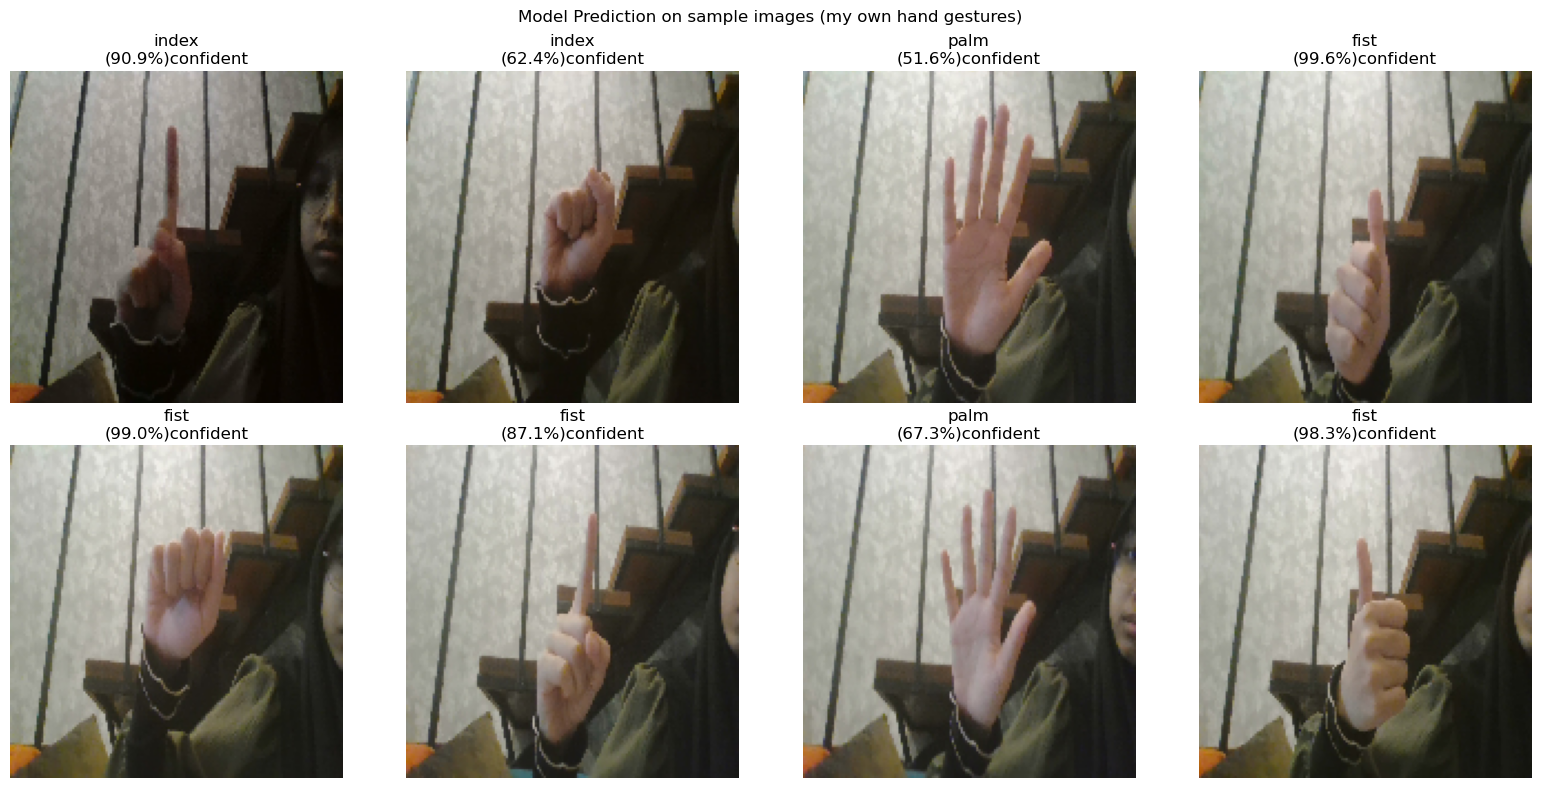

In [26]:
model = joblib.load('model1.joblib')
sample_dir = '../data/sample_images/'

sample_images = [f for f in os.listdir(sample_dir) if f.endswith(('.jpg','.jpeg','.png','.webp'))]

fig,axes = plt.subplots(2,4,figsize=(16,8))
axes = axes.flatten()

for i, img_name in enumerate(sample_images[:8]):
    img_path = os.path.join(sample_dir,img_name)
    img = image.load_img(img_path, target_size=(150,150))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array,axis=0)
    img_array = img_array/255.0

    class_names = list(train_generator.class_indices.keys())
    pred  = model.predict(img_array)

    # pred will look like [0.1, 0.2, 0.6, 0.2]
    pred_idx = np.argmax(pred[0])            # index of highest probability
    label = class_names[pred_idx]             # class name
    conf = pred[0][pred_idx] * 100    

    axes[i].imshow(img)
    axes[i].set_title(f'{label}\n({conf:.1f}%)confident')
    axes[i].axis('off')
plt.suptitle('Model Prediction on sample images (my own hand gestures)')
plt.tight_layout()
plt.show()

#### 4 correct. lets try with a cleaner background

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


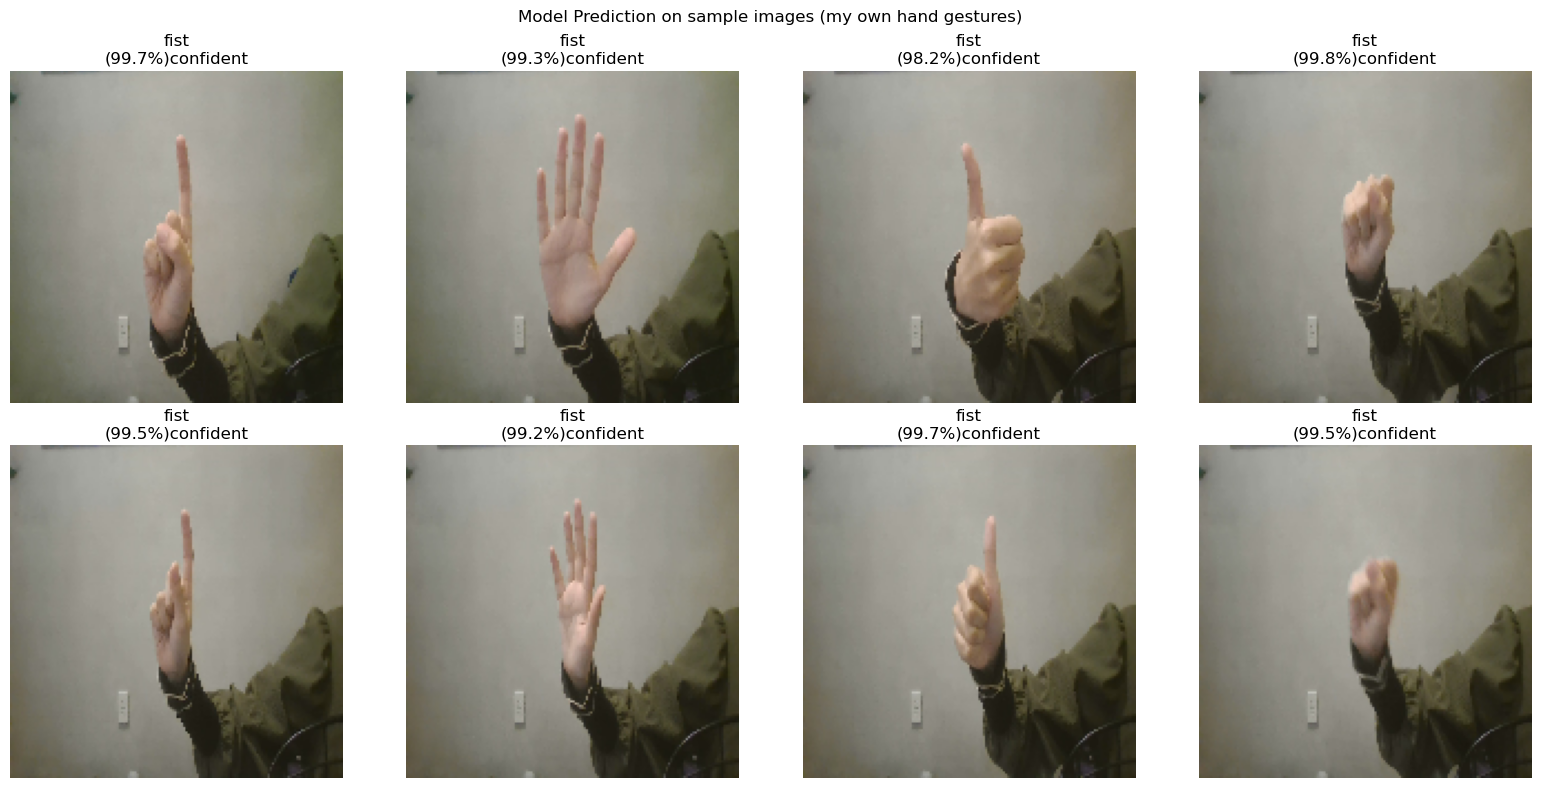

In [27]:
sample_dir = '../data/sample_images/'

sample_images = [f for f in os.listdir(sample_dir) if f.endswith(('.jpg','.jpeg','.png','.webp'))]

fig,axes = plt.subplots(2,4,figsize=(16,8))
axes = axes.flatten()

for i, img_name in enumerate(sample_images[:8]):
    img_path = os.path.join(sample_dir,img_name)
    img = image.load_img(img_path, target_size=(150,150))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array,axis=0)
    img_array = img_array/255.0

    class_names = list(train_generator.class_indices.keys())
    pred  = model.predict(img_array)

    # pred will look like [0.1, 0.2, 0.6, 0.2]
    pred_idx = np.argmax(pred[0])            # index of highest probability
    label = class_names[pred_idx]             # class name
    conf = pred[0][pred_idx] * 100    

    axes[i].imshow(img)
    axes[i].set_title(f'{label}\n({conf:.1f}%)confident')
    axes[i].axis('off')
plt.suptitle('Model Prediction on sample images (my own hand gestures)')
plt.tight_layout()
plt.show()

#### all fist. uh oh
#### I assume that there's not much variation in the dataset, so it's having trouble predicting images out of the ordinary